# Local STARE-PODS Demo — no AWS / no RDS

Mirrors `demo_reconstitute_hdf5_from_s3.py` but uses the **local filesystem** for Parquet storage and **SQLite** for metadata. No cloud credentials needed.

**Core workflow**

1. **Ingest granules from four instruments** (GMI, SSMIS, AMSR2, ATMS) → local Parquet + SQLite metadata (four instruments so the overlap analytics in step 10 can show 2-, 3- and 4-way rendezvous)
2. **Find intersecting data** via STARE SIDs (bbox filter optional; default loads the full granule)
3. **Load intersecting Parquet partitions** from disk
4. **Reconstitute HDF5** (S1 + S2 scans)
5. **Structure comparison** — reconstituted vs original
6. **SQLite metadata verification**

**Temporal features**

7. **Temporal catalog** — every chunk carries `[t_start, t_end]` + podcode
8. **Period-filtered intersection** — data-level `[t_start, t_end]` overlap
9. **VCF temporal roll-up** — union range per pod, on the fly
10. **Multi-instrument overlap analytics** — 2-, 3- and 4-way rendezvous

**Plots**

11. **Pod coverage map** — the level-4 pods each instrument's chunks occupy; the rendezvous pods of steps 12–14 outlined (2-/3-/4-way)
12. **Three 2-way rendezvous** up close — the swaths (where) beside their pass windows (when)
13. **Three 3-way rendezvous** — the same view for trios
14. **Two 4-way rendezvous** — all four instruments over one pod

**Spatial + temporal combined**

15. **Spatial+temporal intersection** — a bbox region (→ STARE SIDs) ANDed with the 4-way rendezvous window in a single `find_intersecting_data` call

In [1]:
#import subprocess, sys
#subprocess.check_call([sys.executable, "-m", "pip", "install", "-e",
#                       "/Users/tonhai/workspace/Bayesics/StarePandas_par/stare_demo_add_contruct_parallel",
#                       "-q"])

In [2]:
import os
import sqlite3
import h5py
from starepandas.demo_lib import LocalStarePodsDemo

### Per-cell timing

Every code cell below reports its own wall time, and `CELL_TIMINGS` keeps them for the summary at the end. Useful for seeing where a run actually spends its time — for these demos it is dominated by ingest, not by any of the queries or analytics.

In [3]:
import time
from IPython import get_ipython

CELL_TIMINGS = {}
_cell_start = {}


def _time_pre(info):
    _cell_start['t0'] = time.perf_counter()


def _time_post(result):
    t0 = _cell_start.pop('t0', None)
    if t0 is None:                      # cell failed before pre_run_cell ran
        return
    elapsed = time.perf_counter() - t0
    CELL_TIMINGS[result.execution_count] = elapsed
    print(f"\u23f1  cell [{result.execution_count}] took {elapsed:.2f}s")


_ip = get_ipython()
# Re-running this cell would otherwise stack duplicate hooks.
for _event, _fn in (('pre_run_cell', _time_pre), ('post_run_cell', _time_post)):
    _existing = [f for f in _ip.events.callbacks[_event] if f.__name__ == _fn.__name__]
    for _old in _existing:
        _ip.events.unregister(_event, _old)
    _ip.events.register(_event, _fn)

print("per-cell timing enabled")

per-cell timing enabled


## Configuration

Edit these paths and parameters before running.

In [4]:
# Parquet store + SQLite DB live here
LOCAL_ROOT = "/tmp/stare_pods_local"

# Resolve the sample granules from the in-repo test-data dir so the notebook is
# safe to run anywhere (no dependency on an external sample directory). Override
# the pair with the STAREPODS_SAMPLE_GRANULE* env vars.
import pandas as pd
import starepandas
_REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(starepandas.__file__)))
_GRANULE_DIR = os.path.join(_REPO_ROOT, "tests", "data", "granules")

GRANULE_FILE = os.environ.get(
    "STAREPODS_SAMPLE_GRANULE",
    os.path.join(_GRANULE_DIR,
                 "1C.GPM.GMI.XCAL2016-C.20250101-S112952-E130304.061572.V07B.HDF5"),
)

# GMI + SSMIS are a co-located pair (both 2025-01-01, concurrent orbits) whose
# ground tracks cross within ~3 min in 42 shared pods — the tightest rendezvous
# in the demo data.
SSMIS_GRANULE_FILE = os.environ.get(
    "STAREPODS_SAMPLE_GRANULE_SSMIS",
    os.path.join(_GRANULE_DIR,
                 "1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B.HDF5"),
)

# A pair only ever fills the n=2 column of the slide-9 table. These four
# granules — one per instrument, all later the same day — are a verified
# **4-way** rendezvous: over pods q003200 and q003203 the passes arrive
# SSMIS 21:29 -> AMSR2 21:46 -> ATMS 21:47 -> GMI 22:13, i.e. all four within
# ~45 min. Ingesting them alongside the pair populates every cell of the
# slide-8 matrix and the n=2/3/4 columns of the slide-9 table from real data.
# The two windows are ~9 h apart, so they never cross-contaminate.
RENDEZVOUS_GRANULES = [
    ("SSMIS", os.path.join(_GRANULE_DIR,
              "1C.F18.SSMIS.XCAL2021-V.20250101-S195732-E213923.078446.V07B.HDF5")),
    ("AMSR2", os.path.join(_GRANULE_DIR,
              "1C.GCOMW1.AMSR2.XCAL2016-V.20250101-S201914-E215806.067167.V07A.HDF5")),
    ("ATMS",  os.path.join(_GRANULE_DIR,
              "1C.NOAA21.ATMS.XCAL2023-V.20250101-S201707-E215835.011117.V07A.HDF5")),
    ("GMI",   os.path.join(_GRANULE_DIR,
              "1C.GPM.GMI.XCAL2016-C.20250101-S204910-E222221.061578.V07B.HDF5")),
]

INSTRUMENTS = ["GMI", "SSMIS", "AMSR2", "ATMS"]

# Coincidence window for step 10. The four passes above span ~45 min, so a
# narrower window still shows 2- and 3-way rendezvous but no 4-way.
OVERLAP_DT = pd.Timedelta(minutes=45)

# Steps 2-5 reconstitute GRANULE_FILE specifically, but two GMI granules are
# now ingested. This granule-level bound on "RawData Collected Time" (the
# filename-derived collection time, i.e. each granule's S... start: 11:29 vs
# 20:49) keeps those steps scoped to the first — distinct from the data-level
# `period` filter demonstrated in step 8.
PRIMARY_GRANULE_END_DATE = "2025-01-01T12:00:00"

# An instant lying in the ~7 h gap between the two GMI passes (which cover
# 11:29-13:03 and 20:49-22:22). Step 8 uses it to split the chunks by their
# data-level range.
PASS_SPLIT = pd.Timestamp("2025-01-01T16:00:00")

# STARE partition level used for both ingestion and bbox → SIDs lookup.
# Capped at MAX_PARTITION_LEVEL = 4 (~256 cells/granule), the regime
# where each Parquet partition is multi-MB — ideal for S3.
STARE_LEVEL = 4

# Bounding box filter — set to None to reconstitute the full granule,
# or e.g. (115, -30, 120, -25) to restrict to SW Australia / Perth.
BBOX = None   # (lon_min, lat_min, lon_max, lat_max) or None

DATASETS = ["GMI_S1", "GMI_S2"]

OUTPUT_HDF5 = "/tmp/reconsitution/gmi_local_reconstituted.h5"

# Set to True to wipe LOCAL_ROOT before each run.
# IMPORTANT: re-running without cleaning causes duplicate SQLite entries,
# which inflates the reconstituted HDF5 (e.g. 3x the expected scan count).
# Keep True unless you intentionally want to append more granules.
CLEAN_BEFORE_RUN = True

# Reuse whatever a previous run already ingested under LOCAL_ROOT instead of
# wiping and re-ingesting (~85 s). Set False to force a fresh ingest; when
# skipping, the CLEAN_BEFORE_RUN wipe is skipped too.
SKIP_INGEST = True

print(f"Granule    : {os.path.basename(GRANULE_FILE)}")
print(f"SSMIS      : {os.path.basename(SSMIS_GRANULE_FILE)}")
for _instrument, _path in RENDEZVOUS_GRANULES:
    print(f"{_instrument:11s}: {os.path.basename(_path)}")
print(f"Datasets   : {DATASETS}")
print(f"BBox       : {BBOX}  (None = full granule)")
print(f"STARE level: {STARE_LEVEL}")
print(f"Local root : {LOCAL_ROOT}")
print(f"Clean first: {CLEAN_BEFORE_RUN}")
print(f"Skip ingest: {SKIP_INGEST}")

Granule    : 1C.GPM.GMI.XCAL2016-C.20250101-S112952-E130304.061572.V07B.HDF5
SSMIS      : 1C.F18.SSMIS.XCAL2021-V.20250101-S112813-E131004.078441.V07B.HDF5
SSMIS      : 1C.F18.SSMIS.XCAL2021-V.20250101-S195732-E213923.078446.V07B.HDF5
AMSR2      : 1C.GCOMW1.AMSR2.XCAL2016-V.20250101-S201914-E215806.067167.V07A.HDF5
ATMS       : 1C.NOAA21.ATMS.XCAL2023-V.20250101-S201707-E215835.011117.V07A.HDF5
GMI        : 1C.GPM.GMI.XCAL2016-C.20250101-S204910-E222221.061578.V07B.HDF5
Datasets   : ['GMI_S1', 'GMI_S2']
BBox       : None  (None = full granule)
STARE level: 4
Local root : /tmp/stare_pods_local
Clean first: True
Skip ingest: True
⏱  cell [4] took 0.00s


## Step 1 — Ingest GMI, SSMIS, AMSR2 and ATMS granules → local Parquet + SQLite

In [5]:
import shutil

if CLEAN_BEFORE_RUN and not SKIP_INGEST and os.path.exists(LOCAL_ROOT):
    shutil.rmtree(LOCAL_ROOT)
    print(f"Removed existing data at {LOCAL_ROOT}")
else:
    print(f"Skipping cleanup (CLEAN_BEFORE_RUN={CLEAN_BEFORE_RUN})")

Skipping cleanup (CLEAN_BEFORE_RUN=True)
⏱  cell [5] took 0.00s


In [6]:
import time
demo = LocalStarePodsDemo(local_root=LOCAL_ROOT)

if SKIP_INGEST:
    from starepandas.io.granules import load_local_temporal_catalog
    existing = (load_local_temporal_catalog(demo.db_path)
                if os.path.exists(demo.db_path) else pd.DataFrame())
    if existing.empty:
        raise RuntimeError(
            f"SKIP_INGEST=True but nothing is stored under {LOCAL_ROOT}. "
            f"Set SKIP_INGEST=False to ingest the granules first."
        )
    print(f"SKIP_INGEST=True — reusing the {len(existing)} chunk(s) already "
          f"under {LOCAL_ROOT}, across {existing['Dataset'].nunique()} dataset(s).")
    print("Set SKIP_INGEST=False to re-ingest from the granule files.")
else:
    local_paths = demo.ingest_granules(GRANULE_FILE, instrument='GMI', level=STARE_LEVEL)
    print(f"GMI  : written {len(local_paths)} scan path(s).")

    ssmis_paths = demo.ingest_granules(SSMIS_GRANULE_FILE, instrument='SSMIS', level=STARE_LEVEL)
    print(f"SSMIS: written {len(ssmis_paths)} scan path(s).")

    for instrument, path in RENDEZVOUS_GRANULES:
        paths = demo.ingest_granules(path, instrument=instrument, level=STARE_LEVEL)
        print(f"{instrument:5s}: written {len(paths)} scan path(s).  ({os.path.basename(path)})")

SKIP_INGEST=True — reusing the 7156 chunk(s) already under /tmp/stare_pods_local, across 14 dataset(s).
Set SKIP_INGEST=False to re-ingest from the granule files.
⏱  cell [6] took 0.02s


## Step 2 — Find intersecting data via STARE SIDs

In [7]:
if BBOX is not None:
    location_sids = demo.get_sids_for_bbox(*BBOX, level=STARE_LEVEL)
    print(f"Generated {len(location_sids)} SIDs for bbox {BBOX}")
else:
    location_sids = None
    print("No bbox filter — all partitions will be loaded (full granule reconstitution)")

# Two GMI granules are ingested; scope steps 2-5 to the one being reconstituted.
intersecting = demo.find_intersecting_data(location_sids, instruments=['GMI'],
                                           end_date=PRIMARY_GRANULE_END_DATE)
print(f"Found {len(intersecting)} metadata row(s) for {os.path.basename(GRANULE_FILE)}.")
intersecting[['Dataset', 'grouped_id', 'group_path']]

INFO:starepandas.demo_lib:Loaded all 513 partitions for GMI


No bbox filter — all partitions will be loaded (full granule reconstitution)
Found 513 metadata row(s) for 1C.GPM.GMI.XCAL2016-C.20250101-S112952-E130304.061572.V07B.HDF5.


,Dataset,grouped_id,group_path
0,GMI_S1,1819454249457680388,/tmp/stare_pods_local/q03/q030/q0302/q03022/q0...
1,GMI_S1,2206763817411543044,/tmp/stare_pods_local/q03/q033/q0331/q03311/q0...
2,GMI_S1,2269814212194729988,/tmp/stare_pods_local/q03/q033/q0333/q03330/q0...
3,GMI_S1,1826209648898736132,/tmp/stare_pods_local/q03/q030/q0302/q03022/q0...
4,GMI_S1,2276569611635785732,/tmp/stare_pods_local/q03/q033/q0333/q03330/q0...
...,...,...,...
508,GMI_S2,2254051613498933252,/tmp/stare_pods_local/q03/q033/q0332/q03322/q0...
509,GMI_S2,1778921852811345924,/tmp/stare_pods_local/q03/q030/q0301/q03011/q0...
510,GMI_S2,1776670052997660676,/tmp/stare_pods_local/q03/q030/q0301/q03011/q0...
511,GMI_S2,1781173652625031172,/tmp/stare_pods_local/q03/q030/q0301/q03011/q0...


⏱  cell [7] took 0.02s


## Step 3 — Load intersecting Parquet partitions from disk

In [8]:
if not intersecting.empty:
    data_dict = demo.download_and_analyze(
        intersecting,
        instruments=list(intersecting['Dataset'].unique()),
    )
    for ds_name, sdf in data_dict.items():
        print(f"{ds_name}: {len(sdf)} rows, columns: {list(sdf.columns[:6])} …")
        display(sdf.head(3))
else:
    print("No intersecting partitions found.")
    data_dict = {}

INFO:starepandas.demo_lib:✓ Combined 659243 rows for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 659243 rows for GMI_S2


GMI_S1: 659243 rows, columns: ['lat', 'lon', 'sids', 'timestamp', 'Tc1', 'Tc2'] …


,lat,lon,sids,timestamp,Tc1,Tc2,Tc3,Tc4,Tc5,Tc6,...,incidenceAngleIndex5,incidenceAngleIndex6,incidenceAngleIndex7,incidenceAngleIndex8,incidenceAngleIndex9,SCstatus_SCorientation,SCstatus_SClatitude,SCstatus_SClongitude,SCstatus_SCaltitude,SCstatus_FractionalGranuleNumber
0,-60.418663,-77.007088,1820290086553930635,2025-01-01 11:29:53.002,173.179993,108.080002,207.080002,159.630005,233.660004,243.289993,...,1,1,1,1,1,180,-65.10408,-74.582634,451.223267,61572.00012
1,-60.431023,-77.121124,1820285685235480459,2025-01-01 11:29:53.002,172.660004,106.129997,206.289993,157.559998,234.039993,241.669998,...,1,1,1,1,1,180,-65.10408,-74.582634,451.223267,61572.00012
2,-60.443966,-77.234947,1820286429792121643,2025-01-01 11:29:53.002,173.179993,106.599998,204.559998,155.669998,232.119995,240.059998,...,1,1,1,1,1,180,-65.10408,-74.582634,451.223267,61572.00012


GMI_S2: 659243 rows, columns: ['lat', 'lon', 'sids', 'timestamp', 'Tc1', 'Tc2'] …


,lat,lon,sids,timestamp,Tc1,Tc2,Tc3,Tc4,Quality,incidenceAngle,...,sunLocalTime,incidenceAngleIndex1,incidenceAngleIndex2,incidenceAngleIndex3,incidenceAngleIndex4,SCstatus_SCorientation,SCstatus_SClatitude,SCstatus_SClongitude,SCstatus_SCaltitude,SCstatus_FractionalGranuleNumber
0,-60.957882,-76.767624,1820203234296677259,2025-01-01 11:29:53.002,264.320007,264.010010,250.850006,259.510010,0,49.57,...,6.319123,1,1,1,1,180,-65.10408,-74.581406,451.223328,61572.00012
1,-60.968994,-76.870178,1820203112318506923,2025-01-01 11:29:53.002,264.339996,263.239990,250.050003,260.750000,0,49.57,...,6.312288,1,1,1,1,180,-65.10408,-74.581406,451.223328,61572.00012
2,-60.980633,-76.972519,1820209139251676299,2025-01-01 11:29:53.002,267.589996,265.049988,250.809998,261.109985,0,49.57,...,6.305466,1,1,1,1,180,-65.10408,-74.581406,451.223328,61572.00012


⏱  cell [8] took 0.96s


## Step 4 — Reconstitute HDF5 (S1 + S2)

In [9]:
import time
granule_basename = os.path.splitext(os.path.basename(GRANULE_FILE))[0]

recon_path = demo.reconstitute_hdf5(
    dataset=DATASETS,
    output_hdf5_path=OUTPUT_HDF5,
    bbox=BBOX,
    granule_name=granule_basename,
)
print(f"Written to: {recon_path}")

INFO:starepandas.demo_lib:Reconstituting HDF5 for dataset='GMI_S1' over bbox=None


INFO:starepandas.demo_lib:Reconstituting HDF5 for dataset='GMI_S2' over bbox=None


INFO:starepandas.demo_lib:✓ Reconstituted HDF5 written to /tmp/reconsitution/gmi_local_reconstituted.h5


Written to: /tmp/reconsitution/gmi_local_reconstituted.h5
⏱  cell [9] took 1.81s


## Step 5 — Structure comparison: reconstituted vs original

In [10]:
def dump_structure(path, label):
    """Print HDF5 group/dataset tree with shapes and dtypes."""
    print(f"\n--- {label} ---")
    with h5py.File(path, "r") as f:
        def _visit(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  /{name:50s} {str(obj.shape):20s} {obj.dtype}")
            elif isinstance(obj, h5py.Group) and name != "/":
                print(f"  /{name:50s} Group")
        f.visititems(_visit)

dump_structure(recon_path, f"RECONSTITUTED  ({os.path.basename(recon_path)})")
dump_structure(GRANULE_FILE, f"ORIGINAL       ({os.path.basename(GRANULE_FILE)})")


--- RECONSTITUTED  (gmi_local_reconstituted.h5) ---
  /S1                                                 Group
  /S1/Latitude                                        (2983, 221)          float32
  /S1/Longitude                                       (2983, 221)          float32
  /S1/Quality                                         (2983, 221)          int8
  /S1/SCstatus                                        Group
  /S1/SCstatus/FractionalGranuleNumber                (2983,)              float64
  /S1/SCstatus/SCaltitude                             (2983,)              float32
  /S1/SCstatus/SClatitude                             (2983,)              float32
  /S1/SCstatus/SClongitude                            (2983,)              float32
  /S1/SCstatus/SCorientation                          (2983,)              int16
  /S1/ScanTime                                        Group
  /S1/ScanTime/DayOfMonth                             (2983,)              int8
  /S1/ScanTime/DayOfYear    

## Step 6 — SQLite metadata verification

In [11]:
conn = sqlite3.connect(demo.db_path)
rows = conn.execute(
    'SELECT Dataset, COUNT(*) as cnt FROM "PodsMetadata" GROUP BY Dataset ORDER BY Dataset'
).fetchall()
conn.close()

print(f"SQLite DB: {demo.db_path}")
for dataset_name, cnt in rows:
    print(f"  {dataset_name}: {cnt} partition(s)")

SQLite DB: /tmp/stare_pods_local/metadata.db
  AMSR2_S1: 358 partition(s)
  AMSR2_S2: 357 partition(s)
  AMSR2_S3: 357 partition(s)
  AMSR2_S4: 358 partition(s)
  AMSR2_S5: 359 partition(s)
  AMSR2_S6: 356 partition(s)
  ATMS_S1: 502 partition(s)
  ATMS_S2: 501 partition(s)
  GMI_S1: 529 partition(s)
  GMI_S2: 491 partition(s)
  SSMIS_S1: 751 partition(s)
  SSMIS_S2: 750 partition(s)
  SSMIS_S3: 740 partition(s)
  SSMIS_S4: 747 partition(s)
⏱  cell [11] took 0.00s


## Step 7 — Temporal catalog: every chunk carries `[t_start, t_end]` + podcode

Each ingested chunk now records its temporal range and quaternary pod code. `load_local_temporal_catalog` returns the thin projection the analytics use (`podcode / Dataset / t_start / t_end`) — never the heavy `MetadataJson`.

In [12]:
from starepandas.io.granules import load_local_temporal_catalog, load_local_vcf
from starepandas.overlap import (
    rendezvous_events, overlap_matrix, overlap_pod_table, pair_drilldown,
    pod_drilldown,
)

catalog = load_local_temporal_catalog(demo.db_path)
print(f"Thin catalog: {len(catalog)} chunks across {catalog['Dataset'].nunique()} datasets")
display(catalog.groupby('Dataset').agg(
    chunks=('podcode', 'size'),
    first_start=('t_start', 'min'),
    last_end=('t_end', 'max'),
))
catalog.head(6)

Thin catalog: 7156 chunks across 14 datasets


,chunks,first_start,last_end
Dataset,,,
AMSR2_S1,358,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S2,357,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S3,357,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S4,358,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S5,359,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
AMSR2_S6,356,2025-01-01 20:19:15.458,2025-01-01 21:58:07.391
ATMS_S1,502,2025-01-01 20:17:07.136,2025-01-01 21:58:35.136
ATMS_S2,501,2025-01-01 20:17:07.136,2025-01-01 21:58:35.136
GMI_S1,529,2025-01-01 11:29:53.002,2025-01-01 22:22:22.797


,podcode,Dataset,t_start,t_end
0,q031301,SSMIS_S1,2025-01-01 11:28:14.868,2025-01-01 13:08:35.636
1,q031301,SSMIS_S3,2025-01-01 11:28:14.868,2025-01-01 13:08:35.636
2,q031301,SSMIS_S2,2025-01-01 11:28:14.868,2025-01-01 13:08:37.534
3,q031301,SSMIS_S4,2025-01-01 11:28:14.868,2025-01-01 13:08:37.534
4,q031300,SSMIS_S1,2025-01-01 11:28:14.868,2025-01-01 13:09:06.015
5,q031300,SSMIS_S2,2025-01-01 11:28:14.868,2025-01-01 13:09:06.015


⏱  cell [12] took 0.02s


## Step 8 — Period-filtered intersection

`find_intersecting_data(..., period=(start, end))` keeps only chunks whose **data-level** range `[t_start, t_end]` overlaps the period — ANDed with the spatial pod match. Two GMI passes are now ingested, ~9 h apart, so the filter can tell them apart: the same chunks, selected purely on their temporal range rather than on which granule they came from. A window days away returns none. (This is distinct from the granule-level `start_date`/`end_date` filename filter used in step 2.)

In [13]:
gmi = catalog[catalog['Dataset'].str.startswith('GMI')]
passes = {
    "first GMI pass ": gmi[gmi['t_start'] < PASS_SPLIT],
    "second GMI pass": gmi[gmi['t_start'] >= PASS_SPLIT],
}

for label, chunks in passes.items():
    window = (chunks['t_start'].min(), chunks['t_end'].max())
    hit = demo.find_intersecting_data(None, ['GMI'], period=window)
    print(f"{label}: [{window[0]}, {window[1]}]  ({len(chunks)} chunks)")
    print(f"  -> {len(hit)} of {len(gmi)} GMI chunks match this period")

miss_period = (PASS_SPLIT - pd.Timedelta(days=10), PASS_SPLIT - pd.Timedelta(days=9))
miss = demo.find_intersecting_data(None, ['GMI'], period=miss_period)
print(f"9-10 days earlier -> {len(miss)} chunks")

INFO:starepandas.demo_lib:Loaded all 513 partitions for GMI


INFO:starepandas.demo_lib:Loaded all 507 partitions for GMI


first GMI pass : [2025-01-01 11:29:53.002000, 2025-01-01 13:03:04.224000]  (513 chunks)
  -> 513 of 1020 GMI chunks match this period
second GMI pass: [2025-01-01 20:49:11.577000, 2025-01-01 22:22:22.797000]  (507 chunks)
  -> 507 of 1020 GMI chunks match this period
9-10 days earlier -> 0 chunks
⏱  cell [13] took 0.02s


## Step 9 — VCF temporal roll-up

The temporal hierarchy ("Virtual Collection File") is queryable on the fly: `load_local_vcf(db, level)` groups chunks by their level-`level` ancestor pod and returns each pod's union range `[min(t_start), max(t_end)]` plus its child count. Nothing is materialized — a different level just re-groups the same thin load.

In [14]:
vcf = load_local_vcf(demo.db_path, level=1)
print(f"{len(vcf)} level-1 VCF nodes (one per octant subtree)")
vcf

32 level-1 VCF nodes (one per octant subtree)


,podcode,t_start,t_end,n_chunks,n_without_range
0,q000,2025-01-01 21:34:43.136,2025-01-01 22:13:11.550,258,0
1,q001,2025-01-01 11:33:52.836,2025-01-01 22:19:56.548,218,0
2,q002,2025-01-01 11:50:23.955,2025-01-01 21:33:52.469,336,0
3,q003,2025-01-01 11:36:17.138,2025-01-01 22:16:30.299,508,0
4,q010,2025-01-01 20:58:55.956,2025-01-01 21:14:13.026,192,0
5,q011,2025-01-01 21:14:14.925,2025-01-01 21:15:57.455,4,0
6,q012,2025-01-01 12:26:02.360,2025-01-01 12:39:09.856,55,0
7,q013,2025-01-01 21:12:11.510,2025-01-01 21:15:09.986,12,0
8,q020,2025-01-01 12:37:07.982,2025-01-01 21:13:11.568,42,0
9,q021,2025-01-01 12:58:58.431,2025-01-01 20:58:17.199,36,0


⏱  cell [14] took 0.02s


## Step 10 — Multi-instrument overlap analytics

`rendezvous_events` sweeps the catalog for passes simultaneously present in a pod within Δt; the matrix / pod-table / drill-downs all aggregate that one events frame. A rendezvous means a pod where the instruments each have a chunk **and** their pass times fall within Δt — a spatial *and* temporal intersection.

With four instruments ingested, the slide-9 table gains its **n=3 and n=4** columns. The 4-way is real but tight: over pods `q003200`/`q003203` the passes arrive SSMIS 21:29 → AMSR2 21:46 → ATMS 21:47 → GMI 22:13, spanning ~45 min — so Δt has to be at least that wide before all four count as simultaneous. The first cell below shows that progression.

In [15]:
print("How the coincidence window dt widens what counts as a rendezvous:")
for dt in (pd.Timedelta(minutes=15), pd.Timedelta(minutes=30), OVERLAP_DT):
    ev = rendezvous_events(catalog, dt)
    table = overlap_pod_table(ev)
    by_n = {int(n): int(table[n].gt(0).sum()) for n in table.columns}
    print(f"  dt={str(dt).split()[-1]}  {len(ev):5d} events  "
          f"{ev['podcode'].nunique():4d} pods   pods by n-way: {by_n}")

events = rendezvous_events(catalog, OVERLAP_DT)
pod_table = overlap_pod_table(events)
widest = max(pod_table.columns)

print(f"\nInstrument x instrument matrix — pods where A & B rendezvous (slide 8), dt={OVERLAP_DT}:")
display(overlap_matrix(events))

print('Per-pod n-way combination counts (slide 9), widest rendezvous first:')
display(pod_table.sort_values(sorted(pod_table.columns, reverse=True), ascending=False).head(10))

print(f"{int(pod_table[widest].gt(0).sum())} pods see all {widest} instruments; "
      f"{int(pod_table.get(3, pd.Series(dtype=int)).gt(0).sum())} see a 3-way.")

print('GMI-SSMIS pair drill-down (first 8 shared pods + crossing times):')
display(pair_drilldown(events, 'GMI', 'SSMIS').head(8))

pod = pod_table[pod_table[widest].gt(0)].index[0]
print(f'Pod drill-down for {pod} — every combination meeting there:')
display(pod_drilldown(events, pod).drop(columns='times'))

How the coincidence window dt widens what counts as a rendezvous:
  dt=00:15:00   1317 events   399 pods   pods by n-way: {2: 399, 3: 8}
  dt=00:30:00   1673 events   438 pods   pods by n-way: {2: 438, 3: 96}
  dt=00:45:00   1684 events   442 pods   pods by n-way: {2: 442, 3: 101, 4: 2}

Instrument x instrument matrix — pods where A & B rendezvous (slide 8), dt=0 days 00:45:00:


,AMSR2,ATMS,GMI,SSMIS
AMSR2,0,359,43,58
ATMS,359,0,68,81
GMI,43,68,0,47
SSMIS,58,81,47,0


Per-pod n-way combination counts (slide 9), widest rendezvous first:


n_instruments,2,3,4
podcode,,,
q003200,6,4,1
q003203,6,4,1
q000101,3,1,0
q000110,3,1,0
q000111,3,1,0
q000112,3,1,0
q000113,3,1,0
q000132,3,1,0
q000220,3,1,0


2 pods see all 4 instruments; 101 see a 3-way.
GMI-SSMIS pair drill-down (first 8 shared pods + crossing times):


,podcode,frequency,times
0,q001200,2,"[2025-01-01 22:15:32.174000, 2025-01-01 22:15:..."
1,q003200,2,"[2025-01-01 22:13:52.800000, 2025-01-01 22:14:..."
2,q003201,1,[2025-01-01 22:14:11.550000]
3,q003203,2,"[2025-01-01 22:13:39.675000, 2025-01-01 22:13:..."
4,q022200,4,"[2025-01-01 12:57:00.713000, 2025-01-01 12:57:..."
5,q022201,2,"[2025-01-01 12:56:51.101000, 2025-01-01 12:56:..."
6,q022202,2,"[2025-01-01 12:55:24.851000, 2025-01-01 12:55:..."
7,q022203,4,"[2025-01-01 12:56:20.840000, 2025-01-01 12:56:..."


Pod drill-down for q003200 — every combination meeting there:


,instruments,n_instruments,frequency
0,"(AMSR2, ATMS)",2,2
1,"(AMSR2, GMI)",2,2
2,"(AMSR2, SSMIS)",2,6
3,"(ATMS, GMI)",2,2
4,"(ATMS, SSMIS)",2,2
5,"(GMI, SSMIS)",2,2
6,"(AMSR2, ATMS, GMI)",3,2
7,"(AMSR2, ATMS, SSMIS)",3,2
8,"(AMSR2, GMI, SSMIS)",3,2
9,"(ATMS, GMI, SSMIS)",3,2


⏱  cell [15] took 0.06s


## Step 11 — Where each instrument flew: pod coverage map

One panel per instrument, shading the level-4 pods its chunks occupy, with the widest-rendezvous pods outlined in black. The orbital geometry the analytics depend on becomes obvious: GMI's 65° inclination confines it to a ±67° band, while the sun-synchronous instruments (SSMIS, AMSR2, ATMS) run pole to pole. That is why AMSR2–ATMS share hundreds of pods — they are near-co-orbiting — while anything involving GMI is scarcer, and why the 4-way lands at a mid-southern latitude.

The pods steps 12–14 visit up close are outlined here so they can be located on the world map: every **4-way** pod in **black**, the **3-way** example pods in **dark red**, and the **2-way** example pods in **dark green**. (Outlining *every* pod of a width would blanket the map — 341 pods hold a 2-way.) The examples are selected once here, and steps 12–14 reuse the same picks.

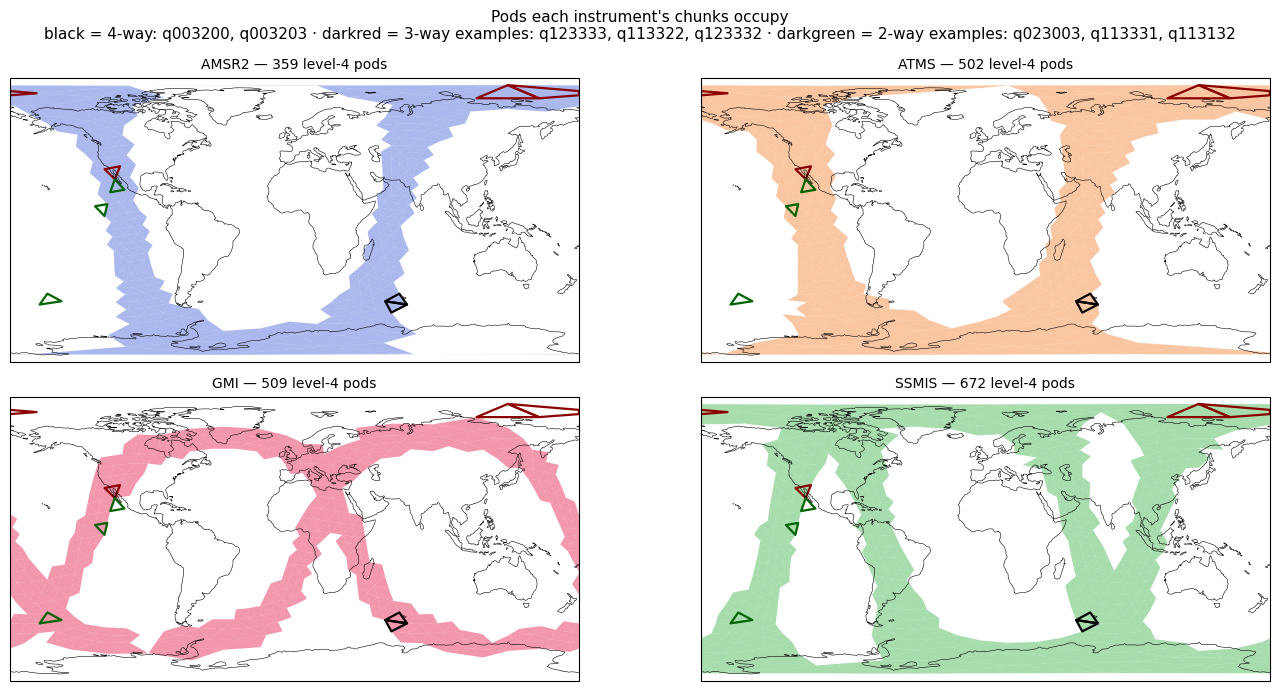

⏱  cell [16] took 2.55s


In [16]:
from starepandas.io.granules import load_local_metadata
from starepandas.demo_plots import (
    plot_pod_coverage, plot_rendezvous, pod_pixels, pod_trixels,
    rendezvous_examples,
)

demo_meta = load_local_metadata(demo.db_path)
examples_by_width = {
    n_way: rendezvous_examples(events, n_way, count=wanted,
                               metadata=demo_meta, window=OVERLAP_DT)
    for n_way, wanted in [(2, 3), (3, 3), (4, 2)]
}
quad_pods = list(pod_table[pod_table[widest].gt(0)].index)
outlines = [
    (quad_pods, 'black', f'{widest}-way'),
    ([p for p, _, _ in examples_by_width[3]], 'darkred', '3-way examples'),
    ([p for p, _, _ in examples_by_width[2]], 'darkgreen', '2-way examples'),
]
fig = plot_pod_coverage(catalog, highlight=outlines)

## Step 12 — 2-way rendezvous up close: where *and* when

A rendezvous needs **both** halves, and one map cannot show them. Left: the swaths inside the pod's trixel — pods are triangles, this one ~500 km across. Right: each instrument's pass window over that pod, all landing inside a single Δt.

Note the granularity: co-location here means *the same level-4 pod*, not the same pixel — the swaths need not physically touch. That is the unit the slide-8/9 analytics count.

Three examples, each a **different pair**. Every pod shown has a widest rendezvous of *exactly* two — otherwise a "2-way" would be illustrated with a pod that also holds a 4-way — and among those, the selector spreads the picks across instrument combinations and prefers the pod whose *least*-covered participant still covers the most pixels, so the picture stays legible. The first is the tightest rendezvous in the demo data: the co-located GMI + SSMIS granules, whose ground tracks cross the same pod within about two minutes of each other.

Steps 13 and 14 repeat the view for trios and for all four.

INFO:starepandas.demo_lib:✓ Combined 8390 rows for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 8801 rows for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 1325 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 1327 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 2775 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 2688 rows for SSMIS_S4


Pod q023003: GMI + SSMIS, rendezvous completes 2025-01-01 12:56:53.118000
  GMI      9435 px  2025-01-01 12:54:28.601000 .. 2025-01-01 12:56:43.601000
  SSMIS    8115 px  2025-01-01 12:56:53.118000 .. 2025-01-01 12:59:36.405000


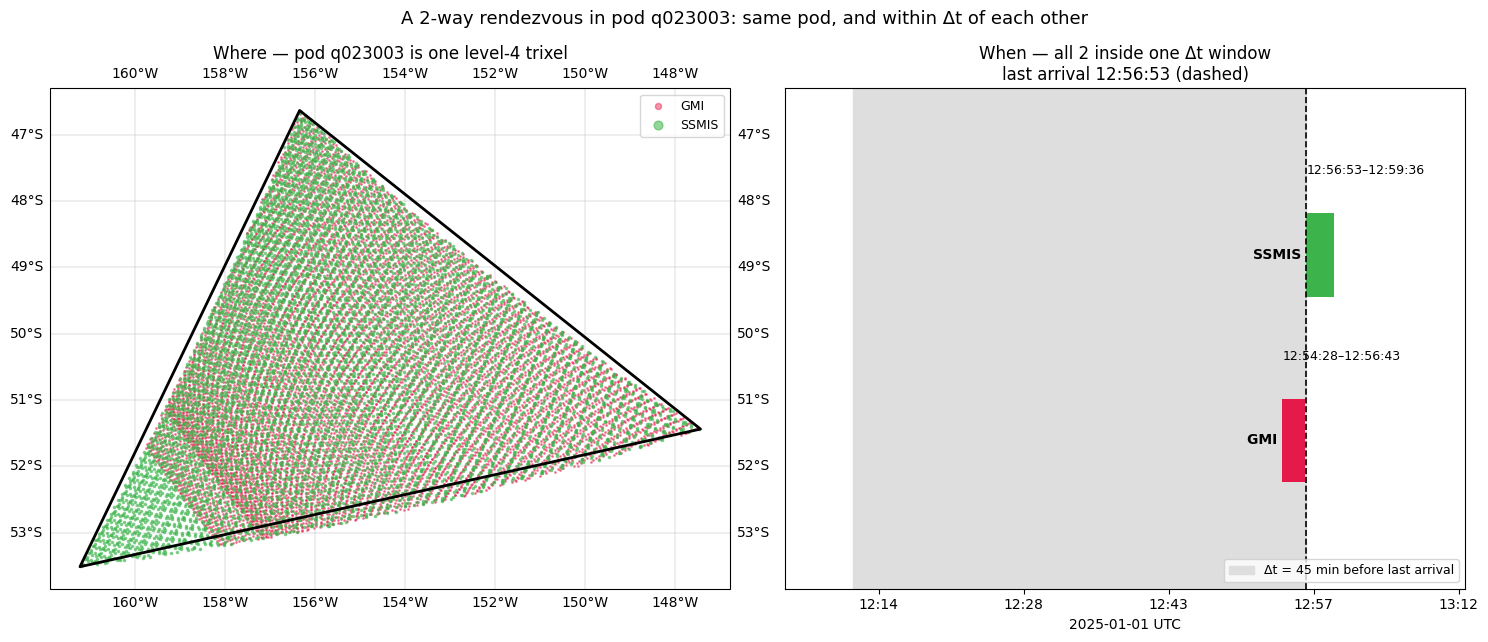

INFO:starepandas.demo_lib:✓ Combined 4510 rows for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 4514 rows for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 4516 rows for AMSR2_S3


INFO:starepandas.demo_lib:✓ Combined 4514 rows for AMSR2_S4


INFO:starepandas.demo_lib:✓ Combined 9019 rows for AMSR2_S5


INFO:starepandas.demo_lib:✓ Combined 9183 rows for AMSR2_S6


INFO:starepandas.demo_lib:✓ Combined 1282 rows for ATMS_S1


INFO:starepandas.demo_lib:✓ Combined 1283 rows for ATMS_S2


Pod q113331: AMSR2 + ATMS, rendezvous completes 2025-01-01 20:47:41.802000
  AMSR2   36256 px  2025-01-01 20:47:04.798000 .. 2025-01-01 20:49:07.787000
  ATMS     2565 px  2025-01-01 20:47:41.802000 .. 2025-01-01 20:49:44.469000


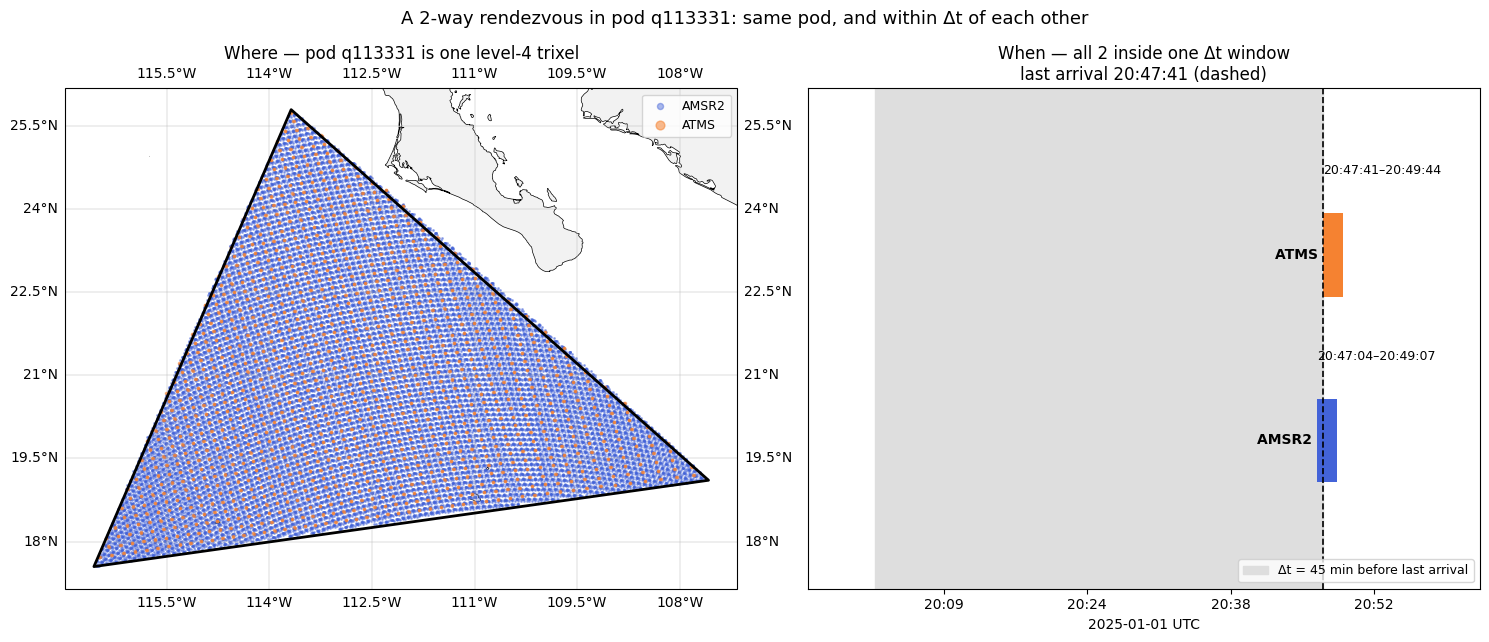

INFO:starepandas.demo_lib:✓ Combined 699 rows for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 472 rows for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 282 rows for ATMS_S1


INFO:starepandas.demo_lib:✓ Combined 282 rows for ATMS_S2


INFO:starepandas.demo_lib:✓ Combined 708 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 705 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 1371 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 1390 rows for SSMIS_S4


Pod q113132: ATMS + GMI, rendezvous completes 2025-01-01 21:15:20.943000
  ATMS      564 px  2025-01-01 20:43:44.469000 .. 2025-01-01 20:45:44.469000
  GMI      1171 px  2025-01-01 21:15:20.943000 .. 2025-01-01 21:16:15.317000


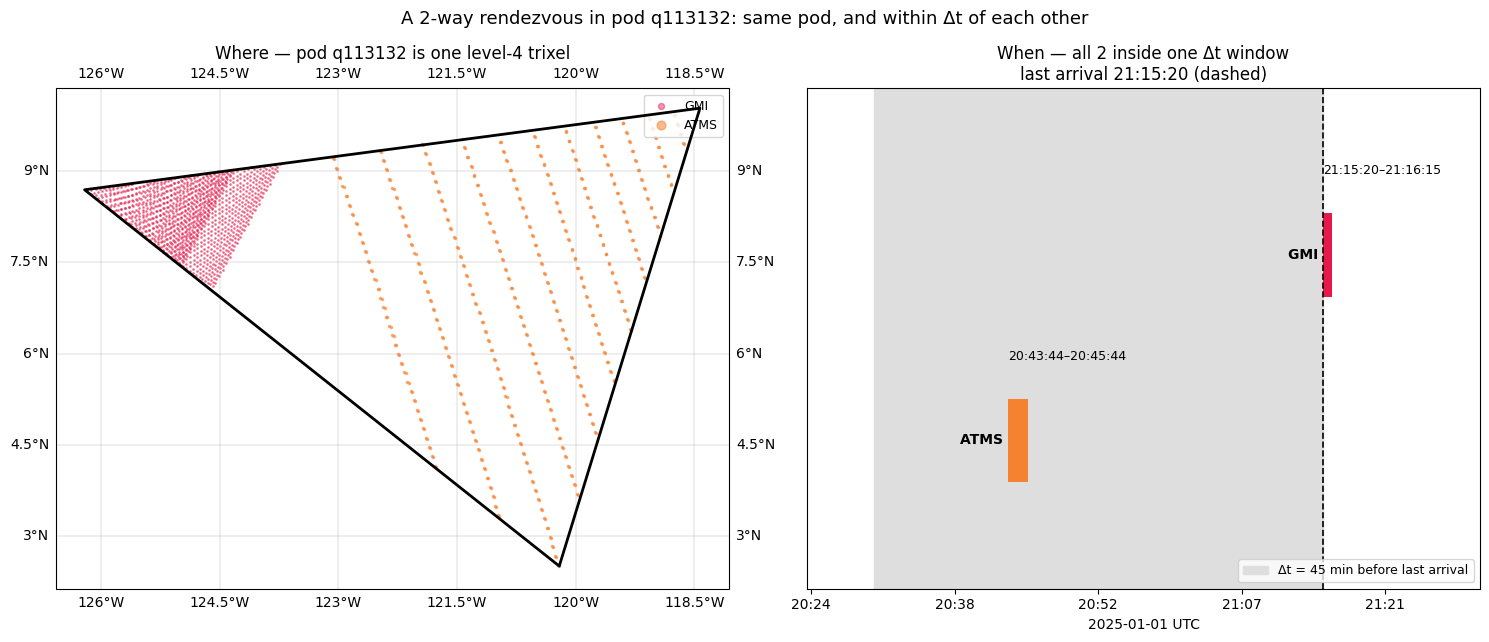

⏱  cell [17] took 5.92s


In [17]:
import matplotlib.pyplot as plt
from IPython.display import display

examples = examples_by_width[2]   # selected in step 11, outlined there

for pod, meeting, n_way in examples:
    window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
    passes = pod_pixels(demo, demo_meta, pod, window)

    print(f"Pod {pod}: {' + '.join(sorted(passes))}, rendezvous completes {meeting}")
    for instrument, pixels in sorted(passes.items(), key=lambda kv: kv[1]['timestamp'].min()):
        print(f"  {instrument:6s} {len(pixels):6d} px  "
              f"{pixels['timestamp'].min()} .. {pixels['timestamp'].max()}")

    fig = plot_rendezvous(pod, passes, meeting, OVERLAP_DT)
    display(fig)
    plt.close(fig)   # already displayed; keeps the inline backend from repeating it


## Step 13 — 3-way rendezvous up close

The same view for **trios** — the n=3 column of the slide-9 table made concrete. Three instruments crossing one pod inside the window, again spread across different instrument combinations where the data allows.

INFO:starepandas.demo_lib:✓ Combined 4604 rows for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 4611 rows for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 4611 rows for AMSR2_S3


INFO:starepandas.demo_lib:✓ Combined 4617 rows for AMSR2_S4


INFO:starepandas.demo_lib:✓ Combined 9217 rows for AMSR2_S5


...

INFO:starepandas.demo_lib:✓ Combined 1510 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 1514 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 3119 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 3056 rows for SSMIS_S4


Pod q123333: AMSR2 + ATMS + SSMIS, rendezvous completes 2025-01-01 21:07:52.469000
  SSMIS    9199 px  2025-01-01 20:47:55.209000 .. 2025-01-01 20:50:34.701000
  AMSR2   37032 px  2025-01-01 21:06:54.185000 .. 2025-01-01 21:09:00.173000
  ATMS     2690 px  2025-01-01 21:07:52.469000 .. 2025-01-01 21:10:05.802000


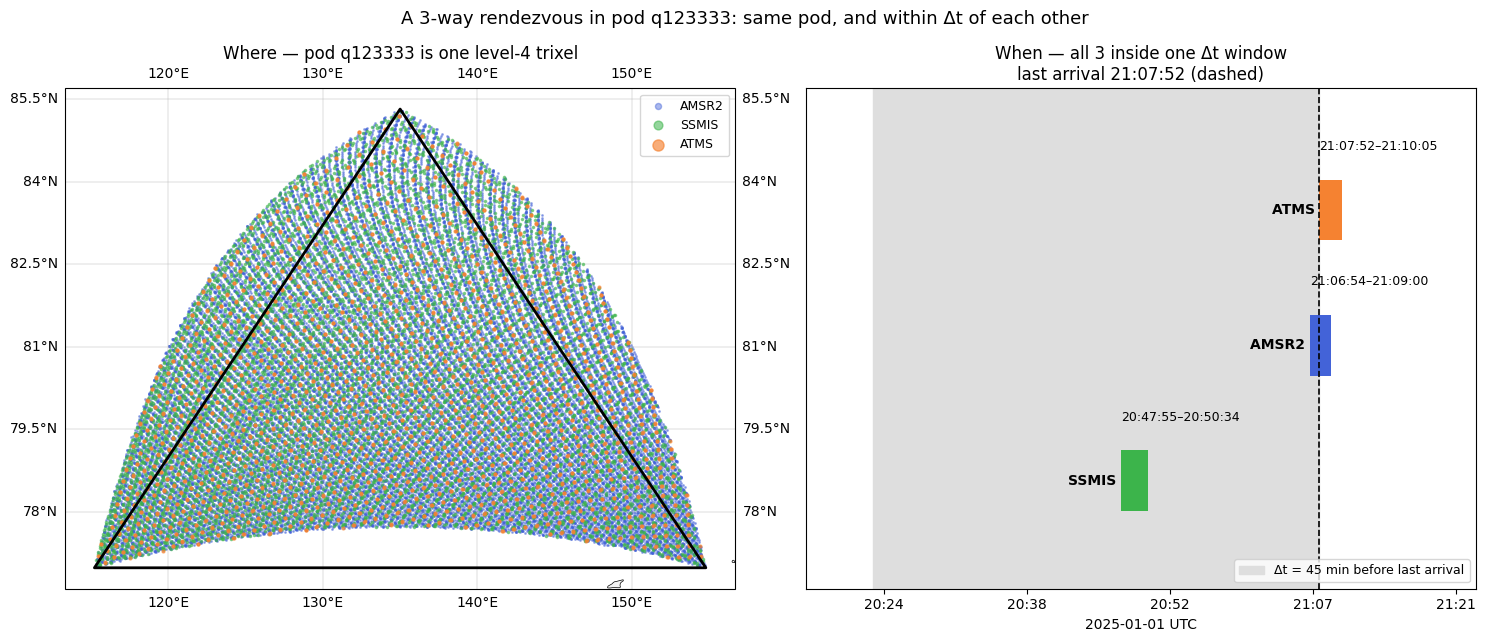

INFO:starepandas.demo_lib:✓ Combined 5525 rows for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 5248 rows for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 4291 rows for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 4292 rows for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 4293 rows for AMSR2_S3


...

INFO:starepandas.demo_lib:✓ Combined 913 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 908 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 1779 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 1801 rows for SSMIS_S4


Pod q113322: AMSR2 + ATMS + GMI, rendezvous completes 2025-01-01 21:21:11.566000
  AMSR2   34493 px  2025-01-01 20:49:07.787000 .. 2025-01-01 20:51:28.773000
  ATMS     2466 px  2025-01-01 20:49:47.136000 .. 2025-01-01 20:51:52.469000
  GMI     10773 px  2025-01-01 21:21:11.566000 .. 2025-01-01 21:23:34.065000


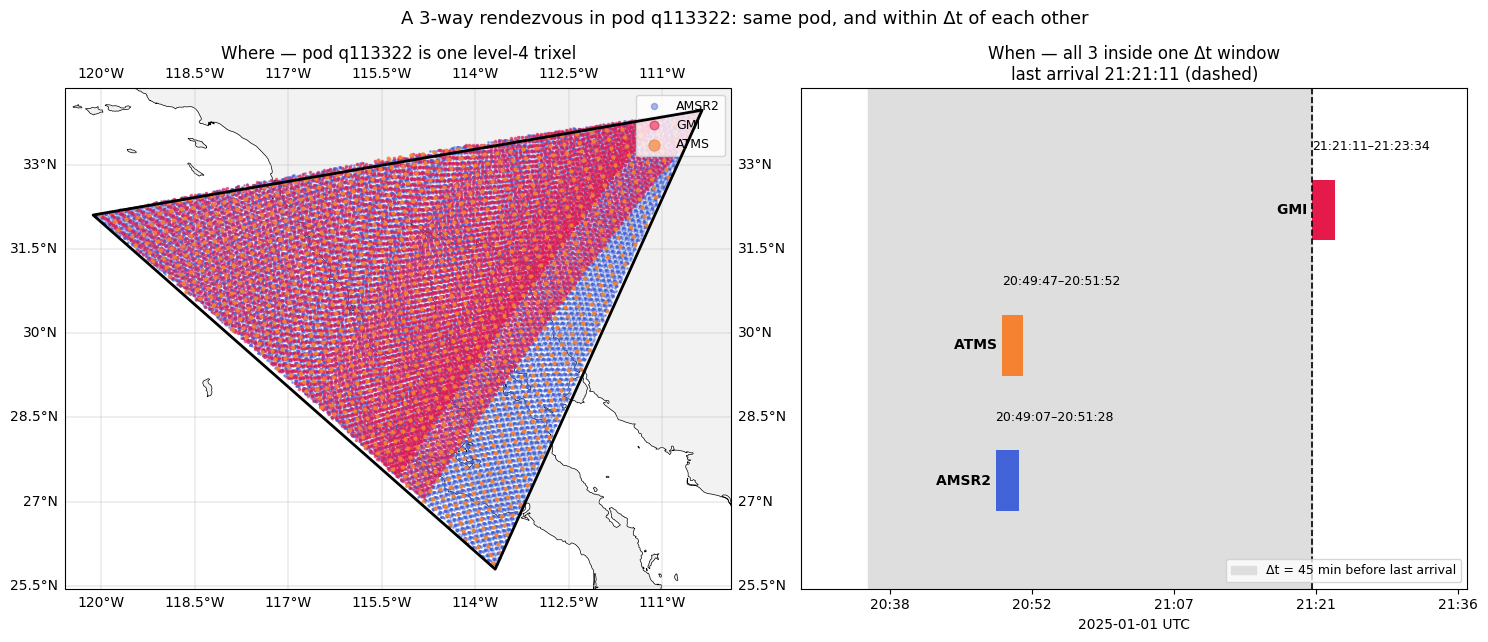

INFO:starepandas.demo_lib:✓ Combined 4509 rows for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 4512 rows for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 4511 rows for AMSR2_S3


INFO:starepandas.demo_lib:✓ Combined 4508 rows for AMSR2_S4


INFO:starepandas.demo_lib:✓ Combined 9019 rows for AMSR2_S5


...

INFO:starepandas.demo_lib:✓ Combined 1293 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 1289 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 2642 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 2627 rows for SSMIS_S4


Pod q123332: AMSR2 + ATMS + SSMIS, rendezvous completes 2025-01-01 21:06:00.469000
  SSMIS    7851 px  2025-01-01 20:46:03.187000 .. 2025-01-01 20:48:29.385000
  AMSR2   36238 px  2025-01-01 21:04:52.697000 .. 2025-01-01 21:07:22.683000
  ATMS     2664 px  2025-01-01 21:06:00.469000 .. 2025-01-01 21:08:13.802000


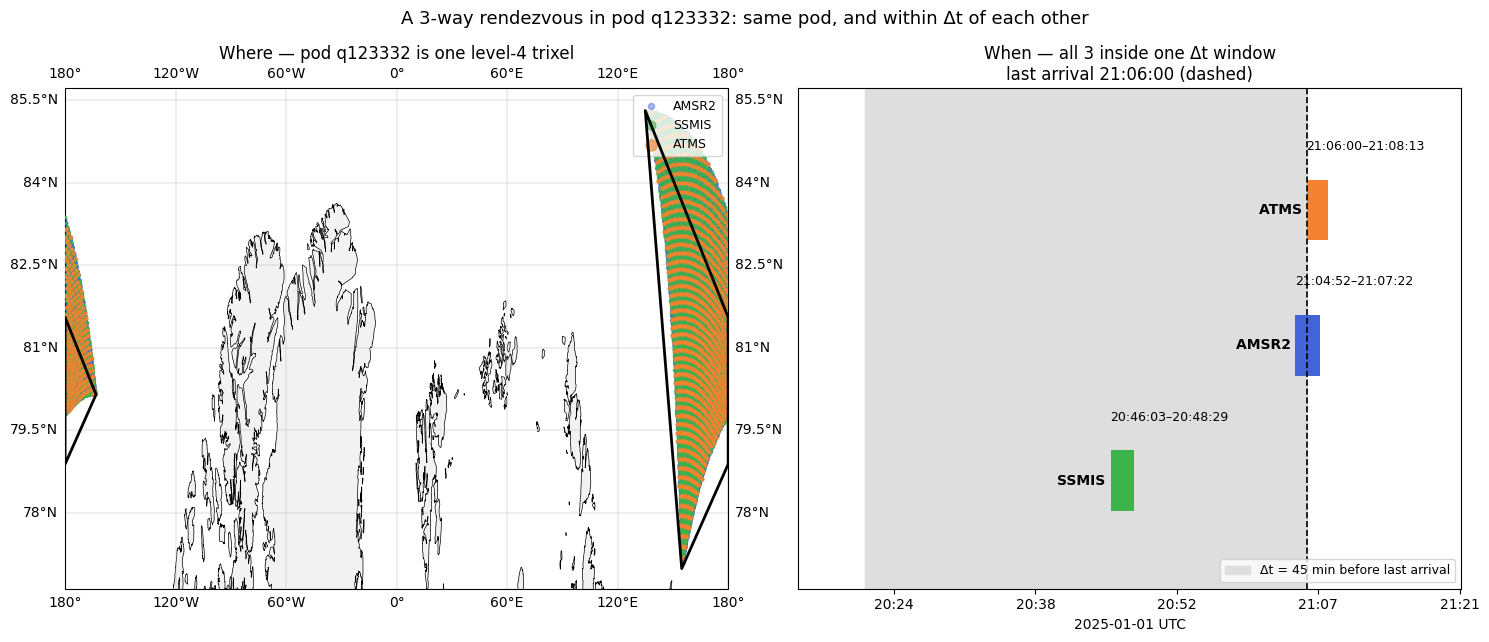

⏱  cell [18] took 1.81s


In [18]:
examples = examples_by_width[3]   # selected in step 11, outlined there

for pod, meeting, n_way in examples:
    window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
    passes = pod_pixels(demo, demo_meta, pod, window)

    print(f"Pod {pod}: {' + '.join(sorted(passes))}, rendezvous completes {meeting}")
    for instrument, pixels in sorted(passes.items(), key=lambda kv: kv[1]['timestamp'].min()):
        print(f"  {instrument:6s} {len(pixels):6d} px  "
              f"{pixels['timestamp'].min()} .. {pixels['timestamp'].max()}")

    fig = plot_rendezvous(pod, passes, meeting, OVERLAP_DT)
    display(fig)
    plt.close(fig)   # already displayed; keeps the inline backend from repeating it


## Step 14 — 4-way rendezvous up close

And all four at once. Only **two** pods in this data hold a 4-way — `q003200` and `q003203`, where the passes arrive SSMIS 21:29 → AMSR2 21:46 → ATMS 21:47 → GMI 22:13 — so both are shown. This is the rendezvous the four extra granules were chosen for, and the reason Δt has to reach 45 min.

INFO:starepandas.demo_lib:✓ Combined 3776 rows for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 3363 rows for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 159 rows for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 156 rows for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 155 rows for AMSR2_S3


...

INFO:starepandas.demo_lib:✓ Combined 835 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 827 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 1549 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 1615 rows for SSMIS_S4


Pod q003200: AMSR2 + ATMS + GMI + SSMIS, rendezvous completes 2025-01-01 22:13:52.800000
  SSMIS     439 px  2025-01-01 21:28:59.716000 .. 2025-01-01 21:30:04.274000
  AMSR2    1102 px  2025-01-01 21:46:25.459000 .. 2025-01-01 21:47:13.454000
  ATMS      284 px  2025-01-01 21:47:39.136000 .. 2025-01-01 21:49:31.136000
  GMI      7139 px  2025-01-01 22:13:52.800000 .. 2025-01-01 22:16:30.299000


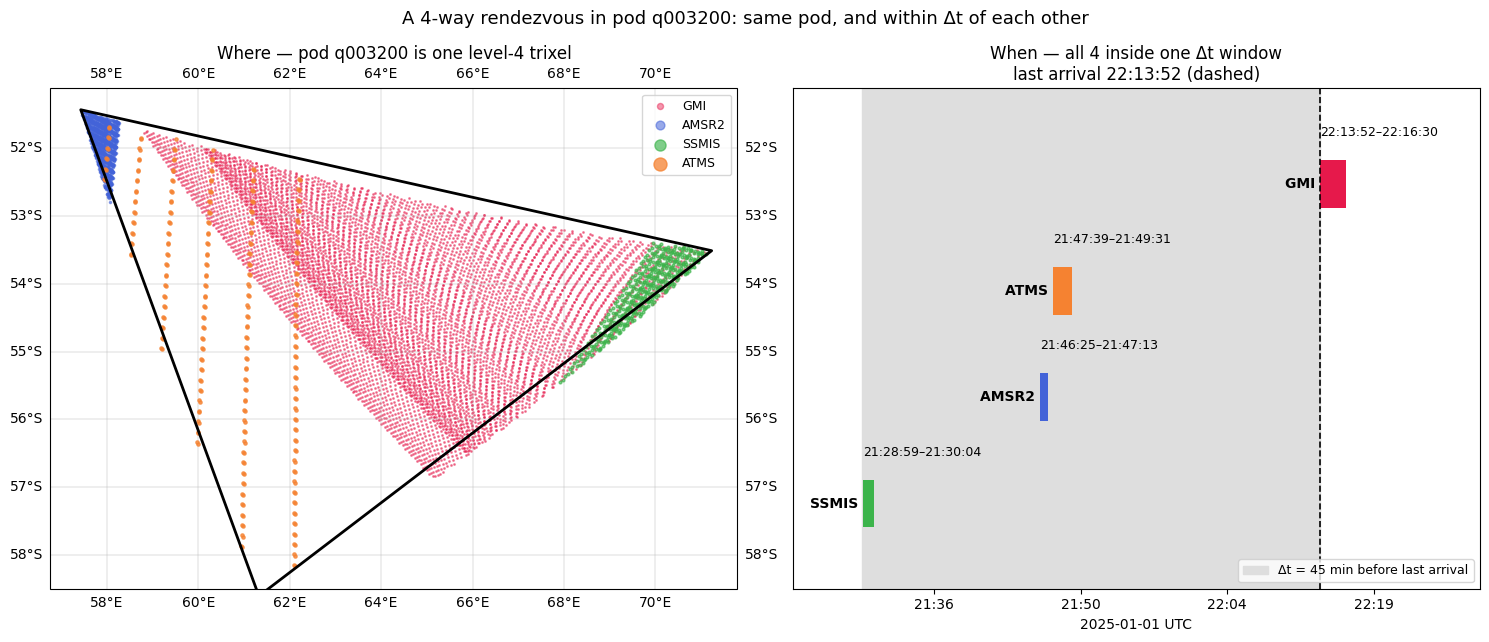

INFO:starepandas.demo_lib:✓ Combined 4484 rows for GMI_S1


INFO:starepandas.demo_lib:✓ Combined 5089 rows for GMI_S2


INFO:starepandas.demo_lib:✓ Combined 85 rows for AMSR2_S1


INFO:starepandas.demo_lib:✓ Combined 82 rows for AMSR2_S2


INFO:starepandas.demo_lib:✓ Combined 83 rows for AMSR2_S3


...

INFO:starepandas.demo_lib:✓ Combined 1194 rows for SSMIS_S1


INFO:starepandas.demo_lib:✓ Combined 1190 rows for SSMIS_S2


INFO:starepandas.demo_lib:✓ Combined 2365 rows for SSMIS_S3


INFO:starepandas.demo_lib:✓ Combined 2386 rows for SSMIS_S4


Pod q003203: AMSR2 + ATMS + GMI + SSMIS, rendezvous completes 2025-01-01 22:13:39.675000
  SSMIS     139 px  2025-01-01 21:28:57.819000 .. 2025-01-01 21:29:24.399000
  AMSR2     578 px  2025-01-01 21:46:25.459000 .. 2025-01-01 21:46:52.456000
  ATMS      146 px  2025-01-01 21:46:53.802000 .. 2025-01-01 21:47:49.802000
  GMI      9573 px  2025-01-01 22:13:39.675000 .. 2025-01-01 22:16:30.299000


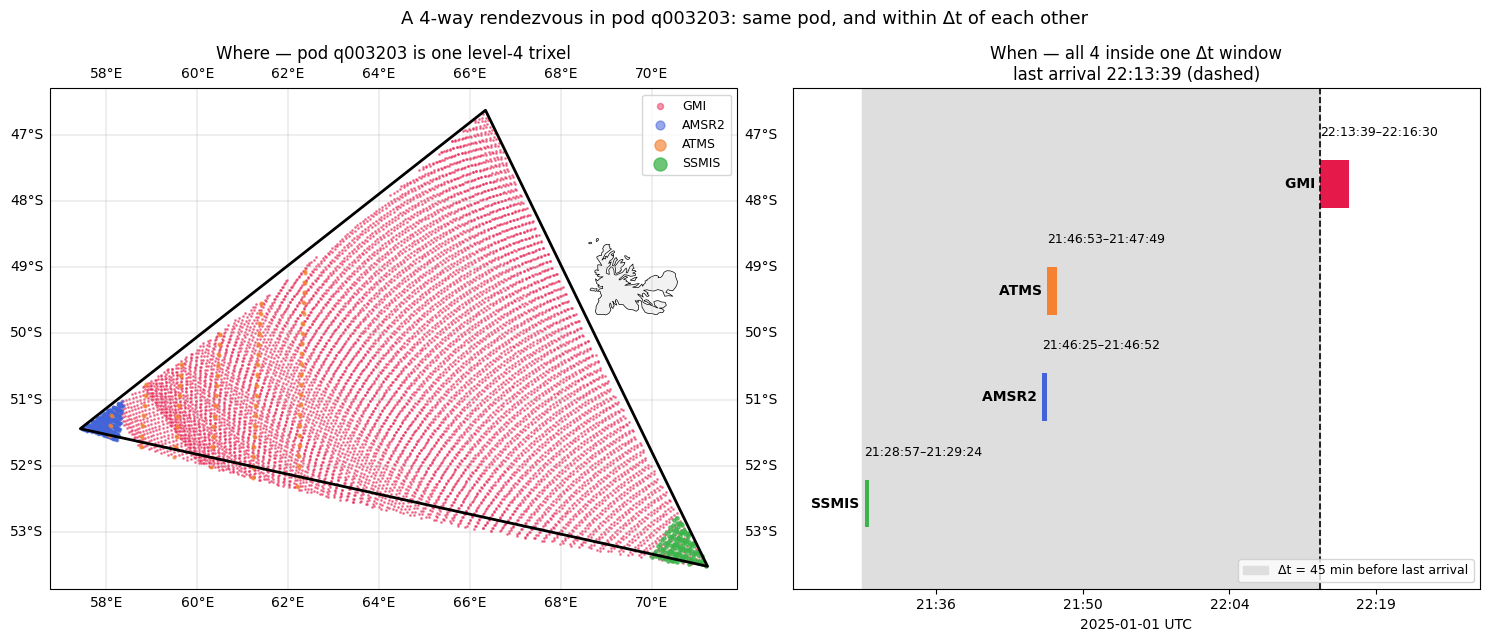

⏱  cell [19] took 0.56s


In [19]:
examples = examples_by_width[4]   # selected in step 11, outlined there

for pod, meeting, n_way in examples:
    window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
    passes = pod_pixels(demo, demo_meta, pod, window)

    print(f"Pod {pod}: {' + '.join(sorted(passes))}, rendezvous completes {meeting}")
    for instrument, pixels in sorted(passes.items(), key=lambda kv: kv[1]['timestamp'].min()):
        print(f"  {instrument:6s} {len(pixels):6d} px  "
              f"{pixels['timestamp'].min()} .. {pixels['timestamp'].max()}")

    fig = plot_rendezvous(pod, passes, meeting, OVERLAP_DT)
    display(fig)
    plt.close(fig)   # already displayed; keeps the inline backend from repeating it


## Step 15 — Spatial+temporal intersection over the 4-way pod

The production question behind everything above: *"which chunks are over **this region** during **this window**?"* Steps 2 and 8 each showed one filter alone; this is the first query to apply **both at once** — the spatial pod match ANDed with the data-level period filter inside a single `find_intersecting_data` call.

The region is a bbox around the 4-way pod's trixel (a scientist's query arrives as lat/lon, not as a pod code), converted to STARE cover SIDs; the window is that rendezvous's own `[meeting ± Δt]`. The contrast with the single-filter queries makes the AND visible: SSMIS crossed the same region on a *morning* orbit too, so the period filter drops those chunks, while the other three instruments (one pass each over the region) keep every spatial match.

In [20]:
from starepandas.overlap import fold_instrument

pod, meeting, _ = examples_by_width[widest][0]
lon_min, lat_min, lon_max, lat_max = pod_trixels([pod]).total_bounds
location_sids = demo.get_sids_for_bbox(lon_min, lat_min, lon_max, lat_max,
                                       level=STARE_LEVEL)
window = (meeting - OVERLAP_DT, meeting + OVERLAP_DT)
print(f"Region: bbox around pod {pod}'s trixel — "
      f"lon [{lon_min:.1f}, {lon_max:.1f}], lat [{lat_min:.1f}, {lat_max:.1f}]"
      f" → {len(location_sids)} level-{STARE_LEVEL} cover SID(s)")
print(f"Window: {window[0]} .. {window[1]}  (the {widest}-way meeting ± Δt)")
print()

spatial_only = demo.find_intersecting_data(location_sids, INSTRUMENTS)
temporal_only = load_local_metadata(demo.db_path, period=window)
both = demo.find_intersecting_data(location_sids, INSTRUMENTS, period=window)
print(f"Temporal only (whole demo footprint in the window): {len(temporal_only):4d} chunk(s)")
print(f"Spatial only  (this region, any time of day):       {len(spatial_only):4d} chunk(s)")
print(f"Spatial AND temporal:                               {len(both):4d} chunk(s)")
print()

per_instrument = (
    both.assign(instrument=both['Dataset'].map(fold_instrument))
        .groupby('instrument')
        .agg(both_filters=('podcode', 'size'),
             first_start=('t_start', 'min'),
             last_end=('t_end', 'max'))
)
per_instrument.insert(0, 'spatial_only', (
    spatial_only.assign(instrument=spatial_only['Dataset'].map(fold_instrument))
    .groupby('instrument').size()
))
print("Per instrument — chunks matching the region alone vs both filters,")
print("and the surviving pass ranges (all four inside the window):")
print(per_instrument.to_string())
print(f"\nThe surviving chunks lie in {both['podcode'].nunique()} pod(s), "
      f"among them the {widest}-way pod(s) "
      f"{sorted(p for p in both['podcode'].unique() if p in quad_pods)}.")

INFO:starepandas.demo_lib:Coerced 13 query SIDs → 13 partition-level IDs


INFO:starepandas.demo_lib:Found 18 intersecting chunks for GMI


INFO:starepandas.demo_lib:Found 68 intersecting chunks for SSMIS


INFO:starepandas.demo_lib:Found 48 intersecting chunks for AMSR2


INFO:starepandas.demo_lib:Found 20 intersecting chunks for ATMS


...

INFO:starepandas.demo_lib:Found 18 intersecting chunks for GMI


INFO:starepandas.demo_lib:Found 30 intersecting chunks for SSMIS


INFO:starepandas.demo_lib:Found 48 intersecting chunks for AMSR2


INFO:starepandas.demo_lib:Found 20 intersecting chunks for ATMS


Temporal only (whole demo footprint in the window): 1478 chunk(s)
Spatial only  (this region, any time of day):        154 chunk(s)
Spatial AND temporal:                                116 chunk(s)

Per instrument — chunks matching the region alone vs both filters,
and the surviving pass ranges (all four inside the window):
            spatial_only  both_filters                 first_start                    last_end
instrument                                                                                    
AMSR2                 48            48  2025-01-01T21:43:37.475000  2025-01-01T21:50:23.936000
ATMS                  20            20  2025-01-01T21:45:33.802000  2025-01-01T21:51:31.136000
GMI                   18            18  2025-01-01T22:11:52.800000  2025-01-01T22:17:43.423000
SSMIS                 68            30  2025-01-01T21:26:18.329000  2025-01-01T21:33:04.649000

The surviving chunks lie in 13 pod(s), among them the 4-way pod(s) ['q003200', 'q003203'].
⏱  cell [20]

## Run time summary

Where the wall clock actually went, slowest cell first.

In [21]:
timings = pd.Series(CELL_TIMINGS, name='seconds').sort_index()
timings.index.name = 'In [n]'
print(f"{len(timings)} timed cells, {timings.sum():.1f}s total "
      f"({timings.sum() / 60:.1f} min) — excluding this summary cell itself")
display(timings.sort_values(ascending=False).head(10).round(2).to_frame())

17 timed cells, 14.0s total (0.2 min) — excluding this summary cell itself


,seconds
In [n],
17,5.92
16,2.55
9,1.81
18,1.81
8,0.96
19,0.56
20,0.24
15,0.06
13,0.02


⏱  cell [21] took 0.00s
